In [ ]:
# PHYS-2425-Spring-2026-Lab6

import numpy as np
s = 0.2 #m
L = 2#m
k = 9e9
eps = 8.85e-12

qx = np.linspace(-L/2, L/2, 15)
qz = np.linspace(-L/2, L/2, 15)

X, Z = np.meshgrid(qx, qz)

Y_bot = -s/2*np.ones((15, 15))

bot_plate = np.array([X, Y_bot, Z])

#check array
print(np.shape(bot_plate))

Y_top = s/2*np.ones((15, 15))

top_plate = np.array([X, Y_top, Z])
print(np.shape(top_plate))
#find charge at each point
Q_total = 5e-9 #C
Q_per_point = Q_total/(15**2)

print(Q_total/(L**2*eps))

def E_field(pos):
    E = np.zeros(3)
    for i in range(15):
      for j in range(15):
        r_top = pos-bot_plate[:,i,j]
        r_bot = pos-top_plate[:,i,j]
        if np.linalg.norm(r_top) < 0.001 or np.linalg.norm(r_bot)<0.01:
          print("Point too close to capacitor")
          return np.zeros(3)
        E += k*Q_per_point/np.linalg.norm(r_bot)**3*r_bot
        E -= k*Q_per_point/np.linalg.norm(r_top)**3*r_top
    return E

E_test = E_field([-1, -0.1, -1])
E_test2 = E_field([0,0,0])
print(E_test)
print(E_test2)



(3, 15, 15)
(3, 15, 15)
141.24293785310735
Point too close to capacitor
[0. 0. 0.]
[   0.         -120.02782543    0.        ]


Point too close to capacitor


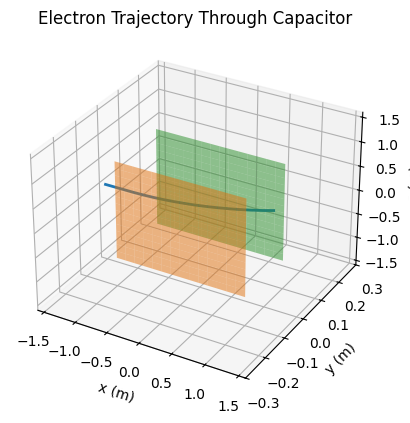

In [ ]:
class particle:
  def __init__(self, q, m, x, v):
    self.q = q
    self.m = m
    self.x = x
    self.v = v

electron = particle(-1.6e-19, 9.11e-31, [-1.5,0,0], [2e7, 0, 0])
t_step = 1e-11

#define as arrays
electron.x = np.array(electron.x, dtype=float)
electron.v = np.array(electron.v, dtype=float)

positions = []   # list to store positions
#counter:
i = 0

while electron.x[0] < 1.5:
    if i>=50000:
      break
    positions.append(electron.x.copy())   # store current position

    E = E_field(electron.x)
    # kill if electron hits capasitor
    if np.linalg.norm(E) == 0:
      break
    F = electron.q * E
    a = F / electron.m

    # Euler update
    electron.v = electron.v + a * t_step
    electron.x = electron.x + electron.v * t_step

    i+=1
# convert to numpy array for plotting
positions = np.array(positions)

#plot
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

# Electron path
ax.plot(positions[:,0], positions[:,1], positions[:,2], linewidth=2)

# Capacitor plates
ax.plot_surface(X, Y_bot, Z, alpha=0.5)
ax.plot_surface(X, Y_top, Z, alpha=0.5)

# Extend limits
ax.set_xlim(-1.6, 1.6)
ax.set_ylim(-0.3, 0.3)
ax.set_zlim(-1.6, 1.6)

ax.set_xlabel("x (m)")
ax.set_ylabel("y (m)")
ax.set_zlabel("z (m)")
ax.set_title("Electron Trajectory Through Capacitor")

plt.show()